# Problem 1: Deriving He Initialization

## 1.1

$$
\mathrm{Var}\left[
\sum_{j=1}^{D_k} w_j^{(k)}h_j^{(k-1)}
\right].
$$

Let

$$
X_j = w_j^{(k)}h_j^{(k-1)}.
$$

For random variables $X_1,\ldots,X_{D_k}$,

$$
\mathrm{Var}\left[\sum_{j=1}^{D_k}X_j\right]
=
\sum_{j=1}^{D_k}\mathrm{Var}[X_j]
+
2\sum_{i<j}\mathrm{Cov}(X_i,X_j).
$$

We assume that the terms $w_j^{(k)}h_j^{(k-1)}$ are mutually
independent (or at least uncorrelated). Therefore, for $i \neq j$,

$$
\mathrm{Cov}(X_i,X_j)=0.
$$

Thus,

$$
\mathrm{Var}\left[
\sum_{j=1}^{D_k} w_j^{(k)}h_j^{(k-1)}
\right]
=
\sum_{j=1}^{D_k}
\mathrm{Var}\left[
w_j^{(k)}h_j^{(k-1)}
\right].
$$

We also assume that the weights $w_j^{(k)}$ are identically
distributed and that the inputs $h_j^{(k-1)}$ are identically
distributed. Therefore, each product has the same variance:

$$
\mathrm{Var}\left[
w_j^{(k)}h_j^{(k-1)}
\right]
=
\mathrm{Var}[w_kh_{k-1}].
$$

Since there are $D_k$ terms,

$$
\boxed{
\mathrm{Var}\left[
\sum_{j=1}^{D_k} w_j^{(k)}h_j^{(k-1)}
\right]
=
D_k\mathrm{Var}[w_kh_{k-1}]
}
$$

Therefore, the assumptions needed are:

1. The terms $w_j^{(k)}h_j^{(k-1)}$ are mutually independent or
   uncorrelated, so the covariance terms are zero.
2. The terms are identically distributed, so they all have the same
   variance.


## 1.2

We want to show that

$$
\boxed{
\mathrm{Var}[w_kh_{k-1}]
=
\mathrm{Var}[w_k]E[h_{k-1}^2]
}
$$

The given identity for two mutually independent random variables
$A$ and $B$ is

$$
\mathrm{Var}[AB]
=
\mathrm{Var}[A]\mathrm{Var}[B]
+
\mathrm{Var}[A]E[B]^2
+
\mathrm{Var}[B]E[A]^2.
$$

Let

$$
A=w_k
\qquad\text{and}\qquad
B=h_{k-1}.
$$

Since $w_k$ and $h_{k-1}$ are assumed to be independent,

$$
\mathrm{Var}[w_kh_{k-1}]
=
\mathrm{Var}[w_k]\mathrm{Var}[h_{k-1}]
+
\mathrm{Var}[w_k]E[h_{k-1}]^2
+
\mathrm{Var}[h_{k-1}]E[w_k]^2.
$$

Under He initialization,

$$
w_k \sim \mathcal{N}\left(0,\frac{2}{D_k}\right).
$$

Therefore,

$$
E[w_k]=0.
$$

Hence,

$$
\mathrm{Var}[h_{k-1}]E[w_k]^2=0.
$$

The expression becomes

$$
\mathrm{Var}[w_kh_{k-1}]
=
\mathrm{Var}[w_k]\mathrm{Var}[h_{k-1}]
+
\mathrm{Var}[w_k]E[h_{k-1}]^2.
$$

Factoring out $\mathrm{Var}[w_k]$ gives

$$
\mathrm{Var}[w_kh_{k-1}]
=
\mathrm{Var}[w_k]
\left(
\mathrm{Var}[h_{k-1}]
+
E[h_{k-1}]^2
\right).
$$

Using the relationship

$$
\mathrm{Var}[B]
=
E[B^2]-E[B]^2,
$$

we can rearrange it as

$$
E[B^2]
=
\mathrm{Var}[B]+E[B]^2.
$$

Therefore,

$$
\mathrm{Var}[h_{k-1}]
+
E[h_{k-1}]^2
=
E[h_{k-1}^2].
$$

Substituting this into the previous expression gives

$$
\boxed{
\mathrm{Var}[w_kh_{k-1}]
=
\mathrm{Var}[w_k]E[h_{k-1}^2]
}
$$

In [1]:
import copy
import itertools
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

In [2]:
# Reproducibility
SEED = 541
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
X_train = np.load("/content/fashion_mnist_train_images.npy").astype(np.float32) / 255.0
y_train = np.load("/content/fashion_mnist_train_labels.npy").astype(np.int64)

X_test = np.load("/content/fashion_mnist_test_images.npy").astype(np.float32) / 255.0
y_test = np.load("/content/fashion_mnist_test_labels.npy").astype(np.int64)

# Flatten 28x28 images -> 784 features
if X_train.ndim == 3:
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)

# Same centering used in the provided starter code
X_train = X_train - 0.5
X_test = X_test - 0.5

# Convert to tensors
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)

X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test)

print("Train:", X_train_t.shape, y_train_t.shape)
print("Test :", X_test_t.shape, y_test_t.shape)

n_features = X_train.shape[1]
n_classes = int(y_train.max() + 1)

print("Input features:", n_features)
print("Classes:", n_classes)

Train: torch.Size([60000, 784]) torch.Size([60000])
Test : torch.Size([10000, 784]) torch.Size([10000])
Input features: 784
Classes: 10


In [4]:
full_train = TensorDataset(X_train_t, y_train_t)

val_size = int(0.2 * len(full_train))
train_size = len(full_train) - val_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train,
    [train_size, val_size],
    generator=generator
)

test_dataset = TensorDataset(X_test_t, y_test_t)

print("Training examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Test examples:", len(test_dataset))

Training examples: 48000
Validation examples: 12000
Test examples: 10000


# Problem 2.1 - Implement the neural network

In [5]:
def build_mlp(input_dim, n_layers, hidden_units, output_dim):
    """
    MLP with:
        n_layers hidden Linear + ReLU layers
        one final Linear output layer

    Example:
        n_layers = 3
        hidden_units = 50

        784 -> 50 -> 50 -> 50 -> 10
    """
    layers = []

    # First hidden layer
    layers.append(nn.Linear(input_dim, hidden_units))
    layers.append(nn.ReLU())
  # Remaining hidden layers
    for _ in range(n_layers - 1):
        layers.append(nn.Linear(hidden_units, hidden_units))
        layers.append(nn.ReLU())

    # Output logits
    layers.append(nn.Linear(hidden_units, output_dim))

    return nn.Sequential(*layers)


In [6]:

# Example model
model = build_mlp(
    input_dim=784,
    n_layers=3,
    hidden_units=50,
    output_dim=10
)

print(model)

Sequential(
  (0): Linear(in_features=784, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=50, bias=True)
  (3): ReLU()
  (4): Linear(in_features=50, out_features=50, bias=True)
  (5): ReLU()
  (6): Linear(in_features=50, out_features=10, bias=True)
)


In [7]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(X)

        # Cross-entropy loss
        loss = criterion(logits, y)

        # Backpropagation
        loss.backward()

        # SGD update
        optimizer.step()

        running_loss += loss.item() * X.size(0)

    return running_loss / len(loader.dataset)

In [8]:
def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)

            logits = model(X)

            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == y).sum().item()
            total += y.size(0)

    return correct / total

# Problem 2.2 - Hyperparameter tuning

In [9]:
def hyperparam_tuning(train_dataset, val_dataset, seed=541):

    torch.manual_seed(seed)
    np.random.seed(seed)

    criterion = nn.CrossEntropyLoss()

    # 12 systematic configurations
    configs = [
        {"n_layers": 3, "hidden_units": 50,  "lr": 0.01,  "batch_size": 64,  "weight_decay": 0.0},
        {"n_layers": 3, "hidden_units": 100, "lr": 0.01,  "batch_size": 64,  "weight_decay": 0.0},
        {"n_layers": 4, "hidden_units": 50,  "lr": 0.01,  "batch_size": 64,  "weight_decay": 0.0},
        {"n_layers": 4, "hidden_units": 100, "lr": 0.01,  "batch_size": 64,  "weight_decay": 0.0},

        {"n_layers": 3, "hidden_units": 100, "lr": 0.05,  "batch_size": 64,  "weight_decay": 0.0},
        {"n_layers": 4, "hidden_units": 100, "lr": 0.05,  "batch_size": 64,  "weight_decay": 0.0},

        {"n_layers": 3, "hidden_units": 100, "lr": 0.01,  "batch_size": 128, "weight_decay": 0.0},
        {"n_layers": 4, "hidden_units": 100, "lr": 0.01,  "batch_size": 128, "weight_decay": 0.0},

        {"n_layers": 3, "hidden_units": 100, "lr": 0.05,  "batch_size": 128, "weight_decay": 0.0},
        {"n_layers": 4, "hidden_units": 100, "lr": 0.05,  "batch_size": 128, "weight_decay": 0.0},

        {"n_layers": 3, "hidden_units": 100, "lr": 0.05,  "batch_size": 64,  "weight_decay": 1e-4},
        {"n_layers": 4, "hidden_units": 100, "lr": 0.05,  "batch_size": 64,  "weight_decay": 1e-4},
    ]

    best_cfg = None
    best_acc = -1.0
    results = []

    tuning_epochs = 20

    for config_id, cfg in enumerate(configs, start=1):

        print("\n" + "=" * 70)
        print(f"Configuration {config_id}/{len(configs)}")
        print(cfg)

        # Same seed gives a fairer comparison
        torch.manual_seed(seed)

        model = build_mlp(
            input_dim=n_features,
            n_layers=cfg["n_layers"],
            hidden_units=cfg["hidden_units"],
            output_dim=n_classes
        ).to(device)

        train_loader = DataLoader(
            train_dataset,
            batch_size=cfg["batch_size"],
            shuffle=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=256,
            shuffle=False
        )

        criterion = nn.CrossEntropyLoss()

        # SGD + L2 regularization
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=cfg["lr"],
            weight_decay=cfg["weight_decay"]
        )

        for epoch in range(tuning_epochs):

            train_loss = train_epoch(
                model,
                train_loader,
                criterion,
                optimizer
            )

        val_acc = evaluate(model, val_loader)

        print(
            f"Final training loss = {train_loss:.4f} | "
            f"Validation accuracy = {val_acc * 100:.2f}%"
        )

        result = cfg.copy()
        result["val_acc"] = val_acc
        results.append(result)

        if val_acc > best_acc:
            best_acc = val_acc
            best_cfg = cfg.copy()

    print("\n" + "=" * 70)
    print("BEST CONFIGURATION")
    print(best_cfg)
    print(f"Best validation accuracy: {best_acc * 100:.2f}%")

    return best_cfg, best_acc, results

In [10]:
best_cfg, best_acc, tuning_results = hyperparam_tuning(
    train_dataset,
    val_dataset
)


Configuration 1/12
{'n_layers': 3, 'hidden_units': 50, 'lr': 0.01, 'batch_size': 64, 'weight_decay': 0.0}
Final training loss = 0.3788 | Validation accuracy = 85.24%

Configuration 2/12
{'n_layers': 3, 'hidden_units': 100, 'lr': 0.01, 'batch_size': 64, 'weight_decay': 0.0}
Final training loss = 0.3669 | Validation accuracy = 85.66%

Configuration 3/12
{'n_layers': 4, 'hidden_units': 50, 'lr': 0.01, 'batch_size': 64, 'weight_decay': 0.0}
Final training loss = 0.3807 | Validation accuracy = 85.85%

Configuration 4/12
{'n_layers': 4, 'hidden_units': 100, 'lr': 0.01, 'batch_size': 64, 'weight_decay': 0.0}
Final training loss = 0.3649 | Validation accuracy = 86.44%

Configuration 5/12
{'n_layers': 3, 'hidden_units': 100, 'lr': 0.05, 'batch_size': 64, 'weight_decay': 0.0}
Final training loss = 0.2426 | Validation accuracy = 87.47%

Configuration 6/12
{'n_layers': 4, 'hidden_units': 100, 'lr': 0.05, 'batch_size': 64, 'weight_decay': 0.0}
Final training loss = 0.2407 | Validation accuracy = 8

In [11]:
import pandas as pd

results_df = pd.DataFrame(tuning_results)

results_df = results_df.sort_values(
    "val_acc",
    ascending=False
).reset_index(drop=True)

results_df["val_acc"] = results_df["val_acc"] * 100

display(results_df)

,n_layers,hidden_units,lr,batch_size,weight_decay,val_acc
0,4,100,0.05,64,0.0000,89.075000
1,4,100,0.05,64,0.0001,88.983333
2,3,100,0.05,128,0.0000,87.833333
3,4,100,0.05,128,0.0000,87.591667
4,3,100,0.05,64,0.0000,87.466667
5,3,100,0.05,64,0.0001,87.391667
6,4,100,0.01,64,0.0000,86.441667
7,4,50,0.01,64,0.0000,85.850000
8,3,100,0.01,64,0.0000,85.658333
9,3,50,0.01,64,0.0000,85.241667


# Problem 2.3 - Retrain the best model

In [12]:
best_model = build_mlp(
    input_dim=n_features,
    n_layers=best_cfg["n_layers"],
    hidden_units=best_cfg["hidden_units"],
    output_dim=n_classes
).to(device)

full_train_loader = DataLoader(
    full_train,
    batch_size=best_cfg["batch_size"],
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    best_model.parameters(),
    lr=best_cfg["lr"],
    weight_decay=best_cfg["weight_decay"]
)

epochs_final = 50

loss_history = []

for epoch in range(epochs_final):

    best_model.train()

    epoch_loss = 0.0

    for X, y in full_train_loader:

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = best_model(X)

        loss = criterion(logits, y)

        loss.backward()

        optimizer.step()

        # Record every SGD/minibatch iteration
        loss_history.append(loss.item())

        epoch_loss += loss.item() * X.size(0)

    epoch_loss /= len(full_train_loader.dataset)

    # Don't need to print every epoch
    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:2d}/{epochs_final} | "
            f"Loss: {epoch_loss:.4f}"
        )

Epoch  5/50 | Loss: 0.3700
Epoch 10/50 | Loss: 0.2979
Epoch 15/50 | Loss: 0.2567
Epoch 20/50 | Loss: 0.2275
Epoch 25/50 | Loss: 0.2023
Epoch 30/50 | Loss: 0.1801
Epoch 35/50 | Loss: 0.1635
Epoch 40/50 | Loss: 0.1463
Epoch 45/50 | Loss: 0.1317
Epoch 50/50 | Loss: 0.1190


In [13]:
test_acc = evaluate(best_model, test_loader)

print("\nBest hyperparameters:")
print(best_cfg)

print(f"\nFinal test accuracy: {test_acc * 100:.2f}%")


Best hyperparameters:
{'n_layers': 4, 'hidden_units': 100, 'lr': 0.05, 'batch_size': 64, 'weight_decay': 0.0}

Final test accuracy: 88.91%


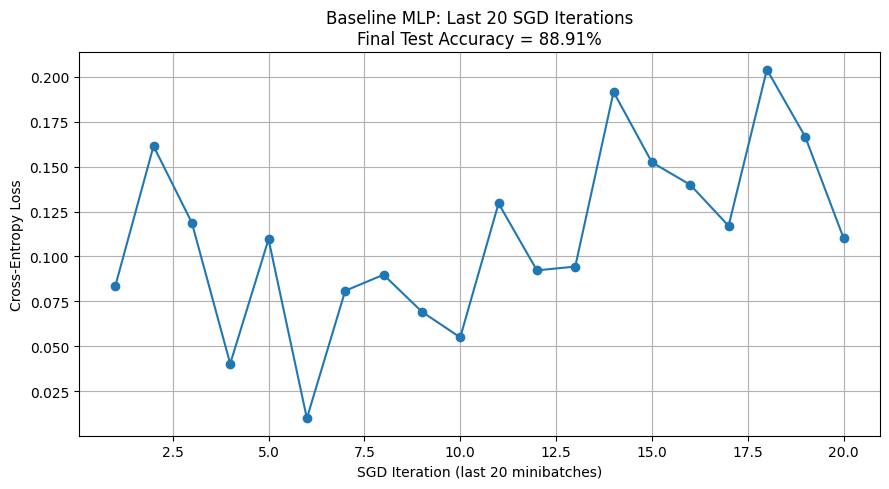

Final Test Accuracy: 88.91%
Best configuration: {'n_layers': 4, 'hidden_units': 100, 'lr': 0.05, 'batch_size': 64, 'weight_decay': 0.0}


In [14]:
last_20_losses = loss_history[-20:]

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, 21),
    last_20_losses,
    marker="o"
)

plt.xlabel("SGD Iteration (last 20 minibatches)")
plt.ylabel("Cross-Entropy Loss")
plt.title(
    f"Baseline MLP: Last 20 SGD Iterations\n"
    f"Final Test Accuracy = {test_acc * 100:.2f}%"
)

plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
print("Best configuration:", best_cfg)

# Problem 2.4 - Improve the architecture

In [15]:
def build_improved_mlp(
    input_dim,
    n_layers,
    hidden_units,
    output_dim
):
    layers = []

    current_dim = input_dim

    for _ in range(n_layers):

        layers.append(
            nn.Linear(current_dim, hidden_units)
        )

        layers.append(
            nn.BatchNorm1d(hidden_units)
        )

        layers.append(
            nn.LeakyReLU(negative_slope=0.01)
        )

        current_dim = hidden_units

    # Raw output logits
    layers.append(
        nn.Linear(hidden_units, output_dim)
    )

    return nn.Sequential(*layers)

In [16]:
torch.manual_seed(SEED)

improved_model = build_improved_mlp(
    input_dim=n_features,
    n_layers=best_cfg["n_layers"],
    hidden_units=best_cfg["hidden_units"],
    output_dim=n_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    improved_model.parameters(),
    lr=best_cfg["lr"],
    weight_decay=best_cfg["weight_decay"],
    momentum=0.9
)

improved_loss_history = []

epochs_improved = 50

for epoch in range(epochs_improved):

    improved_model.train()

    running_loss = 0.0

    for X, y in full_train_loader:

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = improved_model(X)

        loss = criterion(logits, y)

        loss.backward()

        optimizer.step()

        improved_loss_history.append(loss.item())

        running_loss += loss.item() * X.size(0)

    epoch_loss = running_loss / len(full_train_loader.dataset)

    if (epoch + 1) % 5 == 0:

        current_test_acc = evaluate(
            improved_model,
            test_loader
        )

        print(
            f"Epoch {epoch+1:2d}/{epochs_improved} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Test Acc: {current_test_acc * 100:.2f}%"
        )

Epoch  5/50 | Loss: 0.2948 | Test Acc: 88.10%
Epoch 10/50 | Loss: 0.2395 | Test Acc: 88.22%
Epoch 15/50 | Loss: 0.2002 | Test Acc: 87.38%
Epoch 20/50 | Loss: 0.1740 | Test Acc: 88.62%
Epoch 25/50 | Loss: 0.1519 | Test Acc: 89.08%
Epoch 30/50 | Loss: 0.1374 | Test Acc: 88.65%
Epoch 35/50 | Loss: 0.1222 | Test Acc: 88.95%
Epoch 40/50 | Loss: 0.1133 | Test Acc: 89.34%
Epoch 45/50 | Loss: 0.1004 | Test Acc: 89.37%
Epoch 50/50 | Loss: 0.0905 | Test Acc: 89.33%


In [17]:
improved_test_acc = evaluate(
    improved_model,
    test_loader
)

print("=" * 60)
print("RESULTS")
print("=" * 60)

print(
    f"Baseline MLP test accuracy: "
    f"{test_acc * 100:.2f}%"
)

print(
    f"BatchNorm + LeakyReLU test accuracy: "
    f"{improved_test_acc * 100:.2f}%"
)

difference = (
    improved_test_acc - test_acc
) * 100

print(
    f"Difference: {difference:+.2f} percentage points"
)

RESULTS
Baseline MLP test accuracy: 88.91%
BatchNorm + LeakyReLU test accuracy: 89.33%
Difference: +0.42 percentage points


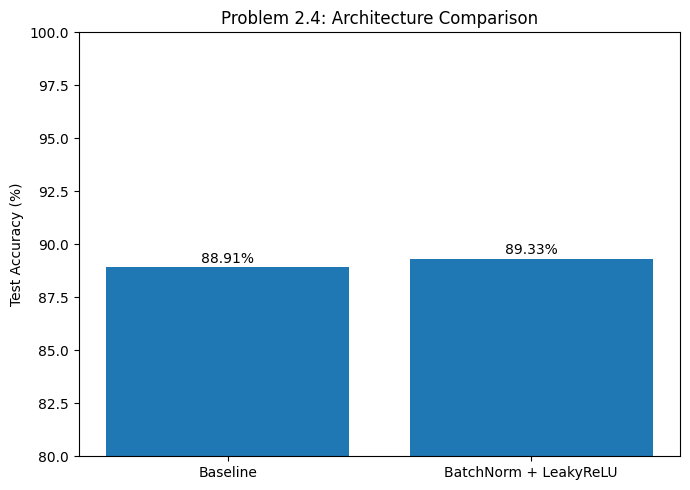

In [18]:
names = ["Baseline", "BatchNorm + LeakyReLU"]

accuracies = [
    test_acc * 100,
    improved_test_acc * 100
]

plt.figure(figsize=(7, 5))

bars = plt.bar(names, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Problem 2.4: Architecture Comparison")
plt.ylim(80, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        acc + 0.2,
        f"{acc:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

# Problem 3

In [19]:
from sklearn.decomposition import PCA


In [20]:
from torch.utils.data import Subset

def extract_model_params(model):
    """Extracts all model parameters into a single flattened tensor."""
    params = []
    for p in model.parameters():
        params.append(p.view(-1))
    return torch.cat(params)

def load_params_into_model(model, param_vector):
    """Loads a flattened parameter vector back into the model."""
    pointer = 0
    for p in model.parameters():
        num_elements = p.numel()
        p.data = param_vector[pointer:pointer + num_elements].view(p.size())
        pointer += num_elements

torch.manual_seed(541)
np.random.seed(541)

# Use only 2500 examples, as suggested by the assignment
subset_indices = np.random.choice(
    len(full_train),
    size=2500,
    replace=False
)

small_dataset = Subset(full_train, subset_indices)

small_loader = DataLoader(
    small_dataset,
    batch_size=64,
    shuffle=True
)

# Create a reasonably small network so the landscape
# computation is not unnecessarily expensive
landscape_model = build_mlp(
    input_dim=n_features,
    n_layers=3,
    hidden_units=30,
    output_dim=n_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    landscape_model.parameters(),
    lr=0.05
)

parameter_history = []

# Store initial parameters
initial_params = extract_model_params(
    landscape_model
).detach().cpu().numpy().copy()

parameter_history.append(initial_params)

epochs_landscape = 20

for epoch in range(epochs_landscape):

    landscape_model.train()

    for batch_idx, (X, y) in enumerate(small_loader):

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = landscape_model(X)

        loss = criterion(logits, y)

        loss.backward()

        optimizer.step()

        # Sample parameter vector a few times per epoch
        if batch_idx % 10 == 0:
            params = extract_model_params(
                landscape_model
            ).detach().cpu().numpy().copy()

            parameter_history.append(params)

    # Always save the end-of-epoch parameters
    params = extract_model_params(
        landscape_model
    ).detach().cpu().numpy().copy()

    parameter_history.append(params)

    print(
        f"Epoch {epoch+1:2d}/{epochs_landscape}, "
        f"loss = {loss.item():.4f}"
    )

print("Number of trajectory points:", len(parameter_history))
print(
    "Parameters per trajectory point:",
    len(parameter_history[0])
)

Epoch  1/20, loss = 2.2406
Epoch  2/20, loss = 2.1330
Epoch  3/20, loss = 1.7402
Epoch  4/20, loss = 2.0470
Epoch  5/20, loss = 1.1848
Epoch  6/20, loss = 1.4716
Epoch  7/20, loss = 0.6737
Epoch  8/20, loss = 2.2757
Epoch  9/20, loss = 0.5639
Epoch 10/20, loss = 1.0016
Epoch 11/20, loss = 1.1294
Epoch 12/20, loss = 0.6051
Epoch 13/20, loss = 0.9621
Epoch 14/20, loss = 0.6633
Epoch 15/20, loss = 0.5287
Epoch 16/20, loss = 0.5927
Epoch 17/20, loss = 0.3382
Epoch 18/20, loss = 0.5178
Epoch 19/20, loss = 0.0417
Epoch 20/20, loss = 0.2924
Number of trajectory points: 101
Parameters per trajectory point: 25720


Suppose the network contains 30,000 trainable parameters.

At one moment during SGD, we flatten all of them into

$$ \theta_t = [w_1,w_2,\ldots,b_1,b_2,\ldots]. $$

After training we therefore have

$$ \theta_0,\theta_1,\theta_2,\ldots,\theta_T. $$

That's what parameter_history contains.

In [21]:
def plotPath(loader, trajectory, model):

    criterion = nn.CrossEntropyLoss()


    trajectory = np.array(trajectory)

    print("Trajectory shape:", trajectory.shape)


    pca = PCA(n_components=2)

    trajectory_2d = pca.fit_transform(trajectory)

    print(
        "PCA explained variance ratio:",
        pca.explained_variance_ratio_
    )

    # Coordinates of actual SGD trajectory
    traj_x = trajectory_2d[:, 0]
    traj_y = trajectory_2d[:, 1]


    x_margin = 0.20 * (traj_x.max() - traj_x.min() + 1e-8)
    y_margin = 0.20 * (traj_y.max() - traj_y.min() + 1e-8)

    x_min = traj_x.min() - x_margin
    x_max = traj_x.max() + x_margin

    y_min = traj_y.min() - y_margin
    y_max = traj_y.max() + y_margin

    # 25 x 25 = 625 network evaluations
    grid_size = 25

    axis1 = np.linspace(
        x_min,
        x_max,
        grid_size
    )

    axis2 = np.linspace(
        y_min,
        y_max,
        grid_size
    )

    Xaxis, Yaxis = np.meshgrid(
        axis1,
        axis2
    )

    Zaxis = np.zeros_like(Xaxis)

    # Save current model parameters so that we can restore them
    original_params = extract_model_params(
        model
    ).detach().clone()



    model.eval()

    for i in range(grid_size):

        print(
            f"Computing landscape row "
            f"{i+1}/{grid_size}"
        )

        for j in range(grid_size):

            # PCA coordinates
            point_2d = np.array([
                [Xaxis[i, j], Yaxis[i, j]]
            ])

            # Convert PCA point back into the original
            # high-dimensional parameter space
            params = pca.inverse_transform(
                point_2d
            )[0]

            params_tensor = torch.tensor(
                params,
                dtype=original_params.dtype,
                device=device
            )

            # Put these parameters into the network
            load_params_into_model(
                model,
                params_tensor
            )

            # Calculate cross-entropy loss
            loss = compute_loss(
                model,
                loader,
                criterion
            )

            Zaxis[i, j] = loss



    trajectory_losses = []

    for params in trajectory:

        params_tensor = torch.tensor(
            params,
            dtype=original_params.dtype,
            device=device
        )

        load_params_into_model(
            model,
            params_tensor
        )

        loss = compute_loss(
            model,
            loader,
            criterion
        )

        trajectory_losses.append(loss)

    trajectory_losses = np.array(
        trajectory_losses
    )



    load_params_into_model(
        model,
        original_params
    )


    fig = plt.figure(
        figsize=(11, 8)
    )

    ax = fig.add_subplot(
        111,
        projection="3d"
    )

    # Loss surface
    ax.plot_surface(
        Xaxis,
        Yaxis,
        Zaxis,
        alpha=0.6,
        cmap="viridis"
    )

    # Actual SGD trajectory
    ax.plot(
        traj_x,
        traj_y,
        trajectory_losses,
        color="red",
        marker="o",
        markersize=4,
        linewidth=2,
        label="SGD trajectory"
    )

    # Initial position
    ax.scatter(
        traj_x[0],
        traj_y[0],
        trajectory_losses[0],
        color="black",
        s=80,
        label="Start"
    )

    # Final position
    ax.scatter(
        traj_x[-1],
        traj_y[-1],
        trajectory_losses[-1],
        color="blue",
        s=80,
        label="End"
    )

    ax.set_xlabel(
        "Principal Component 1"
    )

    ax.set_ylabel(
        "Principal Component 2"
    )

    ax.set_zlabel(
        "Cross-Entropy Loss"
    )

    ax.set_title(
        "Fashion-MNIST Loss Landscape and SGD Trajectory"
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

In [22]:
def compute_loss(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for X, y in loader:

            X = X.to(device)
            y = y.to(device)

            logits = model(X)

            loss = criterion(
                logits,
                y
            )

            running_loss += (
                loss.item() * X.size(0)
            )

    return (
        running_loss /
        len(loader.dataset)
    )

Trajectory shape: (101, 25720)
PCA explained variance ratio: [0.87611705 0.09550731]
Computing landscape row 1/25
Computing landscape row 2/25
Computing landscape row 3/25
Computing landscape row 4/25
Computing landscape row 5/25
Computing landscape row 6/25
Computing landscape row 7/25
Computing landscape row 8/25
Computing landscape row 9/25
Computing landscape row 10/25
Computing landscape row 11/25
Computing landscape row 12/25
Computing landscape row 13/25
Computing landscape row 14/25
Computing landscape row 15/25
Computing landscape row 16/25
Computing landscape row 17/25
Computing landscape row 18/25
Computing landscape row 19/25
Computing landscape row 20/25
Computing landscape row 21/25
Computing landscape row 22/25
Computing landscape row 23/25
Computing landscape row 24/25
Computing landscape row 25/25


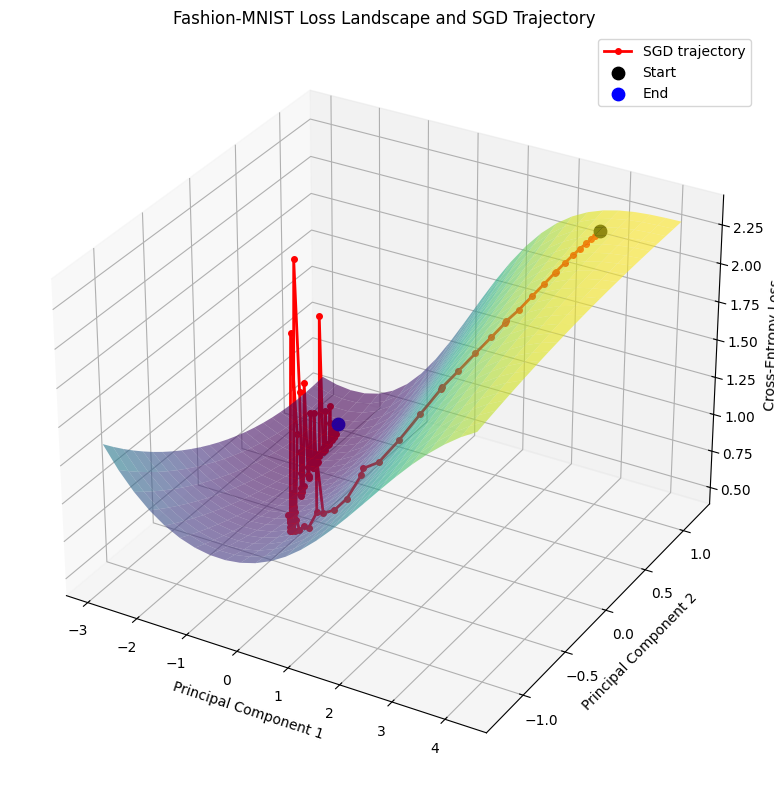

In [23]:
plotPath(
    small_loader,
    parameter_history,
    landscape_model
)

# Problem 4 - Task 1 Data Preparation

In [24]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [25]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


transform = transforms.ToTensor()


train_dataset_ae = datasets.FashionMNIST(
    root="/content/data",
    train=True,
    download=True,
    transform=transform
)

test_dataset_ae = datasets.FashionMNIST(
    root="/content/data",
    train=False,
    download=True,
    transform=transform
)

# DataLoaders
batch_size = 128

train_loader_ae = DataLoader(
    train_dataset_ae,
    batch_size=batch_size,
    shuffle=True
)

test_loader_ae = DataLoader(
    test_dataset_ae,
    batch_size=batch_size,
    shuffle=False
)

print("Training examples:", len(train_dataset_ae))
print("Test examples:", len(test_dataset_ae))

# Check one batch
images, labels = next(iter(train_loader_ae))

print("Image batch shape:", images.shape)
print("Minimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())

Using device: cpu


100%|██████████| 26.4M/26.4M [00:01<00:00, 19.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.9MB/s]

Training examples: 60000
Test examples: 10000
Image batch shape: torch.Size([128, 1, 28, 28])
Minimum pixel value: 0.0
Maximum pixel value: 1.0


# Task 2 - Autoencoder Architecture

In [26]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()


        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )


        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):

        # Compress image
        latent = self.encoder(x)

        # Reconstruct image
        reconstructed = self.decoder(latent)

        return reconstructed


model_ae = Autoencoder().to(device)

print(model_ae)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


# Task 3 - Train the Autoencoder

In [27]:

# Loss function
criterion_ae = nn.MSELoss()

# Adam optimizer
optimizer_ae = torch.optim.Adam(
    model_ae.parameters(),
    lr=0.001
)

num_epochs = 20

training_losses = []

for epoch in range(num_epochs):

    model_ae.train()

    running_loss = 0.0

    for images, _ in train_loader_ae:

        # Move images to GPU/CPU
        images = images.to(device)

        # Flatten:
        # [batch, 1, 28, 28] -> [batch, 784]
        images_flat = images.view(images.size(0), -1)


        reconstructed = model_ae(images_flat)

        # Compare reconstruction with original image
        loss = criterion_ae(
            reconstructed,
            images_flat
        )


        optimizer_ae.zero_grad()

        loss.backward()

        optimizer_ae.step()

        running_loss += (
            loss.item() * images.size(0)
        )

    epoch_loss = (
        running_loss /
        len(train_loader_ae.dataset)
    )

    training_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1:2d}/{num_epochs}] "
        f"Loss: {epoch_loss:.6f}"
    )

Epoch [ 1/20] Loss: 0.037489
Epoch [ 2/20] Loss: 0.019649
Epoch [ 3/20] Loss: 0.016932
Epoch [ 4/20] Loss: 0.015283
Epoch [ 5/20] Loss: 0.014200
Epoch [ 6/20] Loss: 0.013329
Epoch [ 7/20] Loss: 0.012654
Epoch [ 8/20] Loss: 0.012125
Epoch [ 9/20] Loss: 0.011653
Epoch [10/20] Loss: 0.011337
Epoch [11/20] Loss: 0.011032
Epoch [12/20] Loss: 0.010802
Epoch [13/20] Loss: 0.010577
Epoch [14/20] Loss: 0.010376
Epoch [15/20] Loss: 0.010183
Epoch [16/20] Loss: 0.010015
Epoch [17/20] Loss: 0.009841
Epoch [18/20] Loss: 0.009705
Epoch [19/20] Loss: 0.009586
Epoch [20/20] Loss: 0.009439


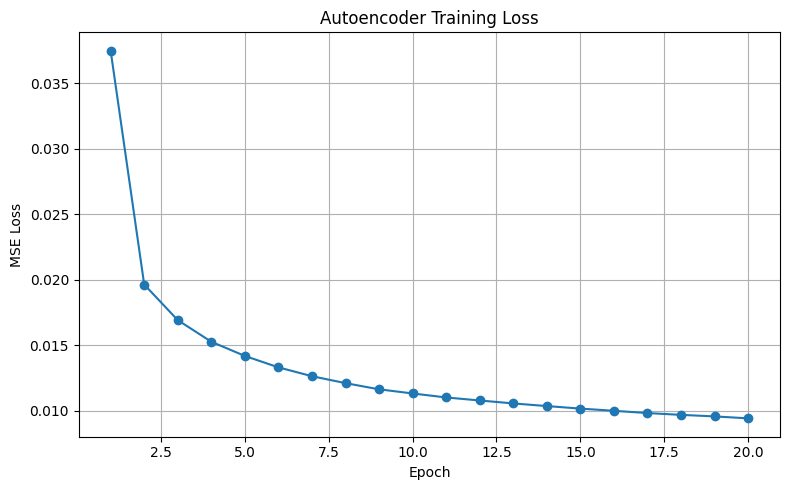

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    training_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

# Task 4 - Visualize the Reconstruction

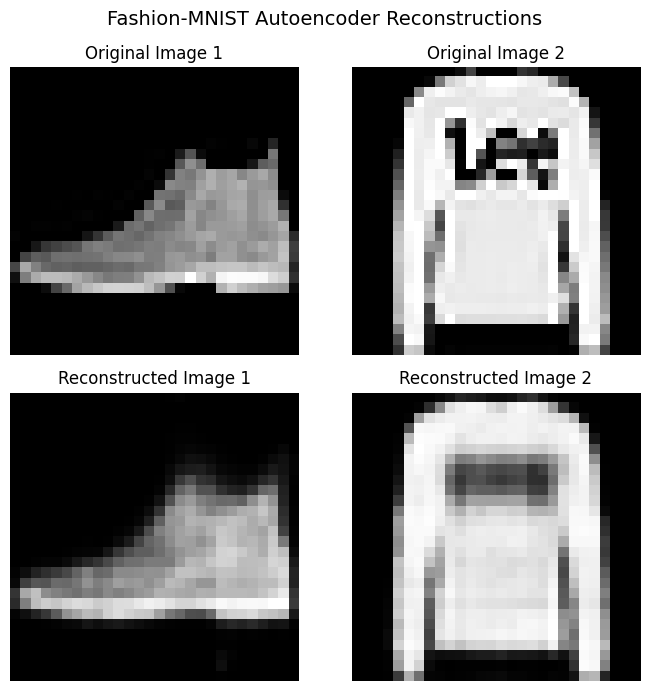

In [29]:
model_ae.eval()

# Get one test batch
test_images, _ = next(iter(test_loader_ae))

# We only need two images
originals = test_images[:2].to(device)

# Flatten them
originals_flat = originals.view(
    originals.size(0),
    -1
)

# Reconstruct
with torch.no_grad():

    reconstructions_flat = model_ae(
        originals_flat
    )

# Convert 784 vectors back to 28x28 images
reconstructions = reconstructions_flat.view(
    -1,
    1,
    28,
    28
)

# Move to CPU for plotting
originals = originals.cpu()
reconstructions = reconstructions.cpu()



fig, axes = plt.subplots(
    2,
    2,
    figsize=(7, 7)
)

# Original image 1
axes[0, 0].imshow(
    originals[0].squeeze(),
    cmap="gray"
)

axes[0, 0].set_title("Original Image 1")
axes[0, 0].axis("off")


# Original image 2
axes[0, 1].imshow(
    originals[1].squeeze(),
    cmap="gray"
)

axes[0, 1].set_title("Original Image 2")
axes[0, 1].axis("off")


# Reconstruction 1
axes[1, 0].imshow(
    reconstructions[0].squeeze(),
    cmap="gray"
)

axes[1, 0].set_title("Reconstructed Image 1")
axes[1, 0].axis("off")


# Reconstruction 2
axes[1, 1].imshow(
    reconstructions[1].squeeze(),
    cmap="gray"
)

axes[1, 1].set_title("Reconstructed Image 2")
axes[1, 1].axis("off")


plt.suptitle(
    "Fashion-MNIST Autoencoder Reconstructions",
    fontsize=14
)

plt.tight_layout()

plt.show()